<a href="https://colab.research.google.com/github/Ankit-K-Jha/LLM-Racial-Bias-Replication/blob/main/Final_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# FINAL STATISTICAL ANALYSIS
# Input : Final_Rater_Analysis.xlsx
# Output: Final_Statistical_Results.xlsx
# ============================================================

# If needed, install packages once:
# !pip -q install openpyxl scipy scikit-learn

import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import cohen_kappa_score
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, PatternFill
from openpyxl.utils import get_column_letter

# ============================================================
# 1. FILE PATH
# ============================================================

INPUT_FILE = "/content/Final_Rater_Analysis.xlsx"
OUTPUT_FILE = "/content/Final_Statistical_Results.xlsx"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(
        f" File not found: {INPUT_FILE}\n"
        "Upload Final_Rater_Analysis.xlsx to Colab and run again."
    )

# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_excel(INPUT_FILE)

print("=" * 80)
print("FINAL STATISTICAL ANALYSIS")
print("=" * 80)
print(f"Input file : {INPUT_FILE}")
print(f"Rows       : {len(df)}")
print(f"Columns    : {len(df.columns)}")
print("=" * 80)

required_cols = [
    "comparison_id",
    "model_name",
    "case_id",
    "comparison_type",
    "original_diagnosis",
    "rater_1_diagnosis_score",
    "rater_1_treatment_score",
    "rater_2_diagnosis_score",
    "rater_2_treatment_score",
    "final_diagnosis_score",
    "final_treatment_score",
]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f" Missing required columns: {missing}")

# ============================================================
# 3. CLEAN / VALIDATE RATINGS
# ============================================================

rating_cols = [
    "rater_1_diagnosis_score",
    "rater_1_treatment_score",
    "rater_2_diagnosis_score",
    "rater_2_treatment_score",
    "final_diagnosis_score",
    "final_treatment_score",
]

for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

invalid_rows = {}

for col in rating_cols:
    bad = df[col].notna() & ~df[col].isin([0, 1, 2, 3])
    invalid_rows[col] = int(bad.sum())

total_invalid = sum(invalid_rows.values())

if total_invalid > 0:
    print("Invalid rating values found:")
    print(invalid_rows)
    raise ValueError(
        "Ratings must be restricted to 0, 1, 2, or 3. "
        "Fix invalid values before continuing."
    )

print(" Rating values validated: all ratings are 0–3 or blank.")

# ============================================================
# 4. NORMALIZE COMPARISON TYPE
# ============================================================

df["comparison_type"] = (
    df["comparison_type"]
    .astype(str)
    .str.strip()
)

# Expected:
# Explicit_vs_Neutral
# Implicit_vs_Neutral

print("\nComparison types:")
print(df["comparison_type"].value_counts(dropna=False))

# ============================================================
# 5. BASIC DATA VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("DATA VALIDATION")
print("=" * 80)

print(f"Total comparisons : {len(df)}")
print(f"Unique comparison IDs : {df['comparison_id'].nunique()}")
print(f"Unique models : {df['model_name'].nunique()}")
print(f"Unique cases : {df['case_id'].nunique()}")

print("\nModel counts:")
print(df["model_name"].value_counts())

print("\nComparison counts:")
print(df["comparison_type"].value_counts())

duplicate_ids = df["comparison_id"].duplicated().sum()

if duplicate_ids:
    print(f" Duplicate comparison IDs: {duplicate_ids}")
else:
    print(" No duplicate comparison IDs.")

# ============================================================
# 6. DESCRIPTIVE STATISTICS FUNCTION
# ============================================================

def descriptive_table(data, group_cols):
    rows = []

    grouped = data.groupby(group_cols, dropna=False)

    for keys, g in grouped:

        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))

        for score_col, label in [
            ("final_diagnosis_score", "Diagnosis"),
            ("final_treatment_score", "Treatment"),
        ]:

            values = pd.to_numeric(
                g[score_col],
                errors="coerce"
            ).dropna()

            n = len(values)

            if n == 0:
                mean = median = sd = min_v = max_v = np.nan
            else:
                mean = values.mean()
                median = values.median()
                sd = values.std(ddof=1) if n > 1 else 0
                min_v = values.min()
                max_v = values.max()

            row[f"{label}_N"] = n
            row[f"{label}_Mean"] = mean
            row[f"{label}_Median"] = median
            row[f"{label}_SD"] = sd
            row[f"{label}_Min"] = min_v
            row[f"{label}_Max"] = max_v

            # Distribution of 0/1/2/3
            for score in [0, 1, 2, 3]:
                count = int((values == score).sum())
                pct = (count / n * 100) if n else np.nan

                row[f"{label}_Score_{score}_N"] = count
                row[f"{label}_Score_{score}_Pct"] = pct

        rows.append(row)

    return pd.DataFrame(rows)

# ============================================================
# 7. OVERALL FINAL SCORE STATISTICS
# ============================================================

overall_stats = descriptive_table(
    df,
    ["comparison_type"]
)

# ============================================================
# 8. MODEL-WISE STATISTICS
# ============================================================

model_stats = descriptive_table(
    df,
    ["model_name", "comparison_type"]
)

# ============================================================
# 9. CASE-WISE STATISTICS
# ============================================================

case_stats = descriptive_table(
    df,
    ["case_id", "comparison_type"]
)

# ============================================================
# 10. MODEL × CONDITION STATISTICS
# ============================================================

model_condition_stats = descriptive_table(
    df,
    ["model_name", "comparison_type"]
)

# ============================================================
# 11. SCORE DISTRIBUTION
# ============================================================

distribution_rows = []

for comparison_type in sorted(df["comparison_type"].dropna().unique()):

    subset = df[df["comparison_type"] == comparison_type]

    for domain, col in [
        ("Diagnosis", "final_diagnosis_score"),
        ("Treatment", "final_treatment_score"),
    ]:

        values = pd.to_numeric(
            subset[col],
            errors="coerce"
        ).dropna()

        n = len(values)

        for score in [0, 1, 2, 3]:

            count = int((values == score).sum())
            pct = count / n * 100 if n else np.nan

            distribution_rows.append({
                "comparison_type": comparison_type,
                "domain": domain,
                "score": score,
                "count": count,
                "percentage": pct
            })

score_distribution = pd.DataFrame(distribution_rows)

# ============================================================
# 12. RATER AGREEMENT
# ============================================================
# Cohen's kappa is calculated only on rows where BOTH raters
# provided a score.
#
# We calculate:
#   Rater 1 vs Rater 2 — Diagnosis
#   Rater 1 vs Rater 2 — Treatment
#
# Because the scale is ordinal (0–3), we report:
#   - Cohen's kappa
#   - weighted Cohen's kappa

def agreement_statistics(data, col1, col2, domain, comparison_type="All"):
    temp = data[[col1, col2]].dropna()

    if len(temp) == 0:
        return {
            "comparison_type": comparison_type,
            "domain": domain,
            "N_rated_by_both": 0,
            "Cohen_kappa": np.nan,
            "Weighted_kappa": np.nan,
            "Exact_agreement_pct": np.nan,
        }

    a = temp[col1].astype(int)
    b = temp[col2].astype(int)

    kappa = cohen_kappa_score(a, b)

    weighted_kappa = cohen_kappa_score(
        a,
        b,
        weights="quadratic"
    )

    exact_agreement = (a == b).mean() * 100

    return {
        "comparison_type": comparison_type,
        "domain": domain,
        "N_rated_by_both": len(temp),
        "Cohen_kappa": kappa,
        "Weighted_kappa": weighted_kappa,
        "Exact_agreement_pct": exact_agreement,
    }


agreement_rows = []

comparison_types = ["All"] + sorted(
    df["comparison_type"].dropna().unique().tolist()
)

for comp in comparison_types:

    subset = (
        df
        if comp == "All"
        else df[df["comparison_type"] == comp]
    )

    agreement_rows.append(
        agreement_statistics(
            subset,
            "rater_1_diagnosis_score",
            "rater_2_diagnosis_score",
            "Diagnosis",
            comp
        )
    )

    agreement_rows.append(
        agreement_statistics(
            subset,
            "rater_1_treatment_score",
            "rater_2_treatment_score",
            "Treatment",
            comp
        )
    )

rater_agreement = pd.DataFrame(agreement_rows)

# ============================================================
# 13. RATER SCORE SUMMARY
# ============================================================

rater_summary_rows = []

for comp in ["All"] + sorted(
    df["comparison_type"].dropna().unique().tolist()
):

    subset = (
        df
        if comp == "All"
        else df[df["comparison_type"] == comp]
    )

    for rater, prefix in [
        ("Rater 1", "rater_1"),
        ("Rater 2", "rater_2"),
        ("Final", "final"),
    ]:

        for domain, suffix in [
            ("Diagnosis", "diagnosis_score"),
            ("Treatment", "treatment_score"),
        ]:

            col = f"{prefix}_{suffix}"

            values = pd.to_numeric(
                subset[col],
                errors="coerce"
            ).dropna()

            rater_summary_rows.append({
                "comparison_type": comp,
                "rater": rater,
                "domain": domain,
                "N": len(values),
                "Mean": values.mean() if len(values) else np.nan,
                "Median": values.median() if len(values) else np.nan,
                "SD": (
                    values.std(ddof=1)
                    if len(values) > 1
                    else 0
                    if len(values) == 1
                    else np.nan
                ),
            })

rater_summary = pd.DataFrame(rater_summary_rows)

# ============================================================
# 14. EXPLICIT vs IMPLICIT COMPARISON
# ============================================================
# This is NOT a replacement for the Neutral baseline analysis.
# It simply provides an additional comparison between the two
# manipulated conditions.

ei_rows = []

explicit = df[
    df["comparison_type"] == "Explicit_vs_Neutral"
]

implicit = df[
    df["comparison_type"] == "Implicit_vs_Neutral"
]

for domain, col in [
    ("Diagnosis", "final_diagnosis_score"),
    ("Treatment", "final_treatment_score"),
]:

    e = pd.to_numeric(
        explicit[col],
        errors="coerce"
    ).dropna()

    i = pd.to_numeric(
        implicit[col],
        errors="coerce"
    ).dropna()

    # Mann–Whitney U is used because the ratings are ordinal.
    if len(e) and len(i):
        u_stat, p_value = stats.mannwhitneyu(
            e,
            i,
            alternative="two-sided"
        )
    else:
        u_stat = p_value = np.nan

    ei_rows.append({
        "domain": domain,
        "Explicit_N": len(e),
        "Explicit_Mean": e.mean() if len(e) else np.nan,
        "Implicit_N": len(i),
        "Implicit_Mean": i.mean() if len(i) else np.nan,
        "Mean_difference_Explicit_minus_Implicit": (
            e.mean() - i.mean()
            if len(e) and len(i)
            else np.nan
        ),
        "Mann_Whitney_U": u_stat,
        "p_value": p_value,
    })

explicit_vs_implicit = pd.DataFrame(ei_rows)

# ============================================================
# 15. MODEL-WISE EXPLICIT vs IMPLICIT
# ============================================================

model_ei_rows = []

for model in sorted(df["model_name"].dropna().unique()):

    explicit_m = df[
        (df["model_name"] == model) &
        (df["comparison_type"] == "Explicit_vs_Neutral")
    ]

    implicit_m = df[
        (df["model_name"] == model) &
        (df["comparison_type"] == "Implicit_vs_Neutral")
    ]

    for domain, col in [
        ("Diagnosis", "final_diagnosis_score"),
        ("Treatment", "final_treatment_score"),
    ]:

        e = pd.to_numeric(
            explicit_m[col],
            errors="coerce"
        ).dropna()

        i = pd.to_numeric(
            implicit_m[col],
            errors="coerce"
        ).dropna()

        if len(e) and len(i):
            u_stat, p_value = stats.mannwhitneyu(
                e,
                i,
                alternative="two-sided"
            )
        else:
            u_stat = p_value = np.nan

        model_ei_rows.append({
            "model_name": model,
            "domain": domain,
            "Explicit_N": len(e),
            "Explicit_Mean": e.mean() if len(e) else np.nan,
            "Implicit_N": len(i),
            "Implicit_Mean": i.mean() if len(i) else np.nan,
            "Explicit_minus_Implicit": (
                e.mean() - i.mean()
                if len(e) and len(i)
                else np.nan
            ),
            "Mann_Whitney_U": u_stat,
            "p_value": p_value,
        })

model_explicit_vs_implicit = pd.DataFrame(model_ei_rows)

# ============================================================
# 16. FINAL SCORE PER COMPARISON
# ============================================================

final_scores = df[
    [
        "comparison_id",
        "model_name",
        "case_id",
        "case_label",
        "comparison_type",
        "final_diagnosis_score",
        "final_treatment_score",
        "final_notes",
    ]
].copy()

# ============================================================
# 17. COMPLETENESS SUMMARY
# ============================================================

completeness_rows = []

for col in rating_cols:
    n_total = len(df)
    n_filled = df[col].notna().sum()

    completeness_rows.append({
        "rating_column": col,
        "total_rows": n_total,
        "completed_ratings": n_filled,
        "missing_ratings": n_total - n_filled,
        "completion_percentage": (
            n_filled / n_total * 100
            if n_total
            else np.nan
        )
    })

rating_completeness = pd.DataFrame(completeness_rows)

# ============================================================
# 18. ROUND NUMERIC RESULTS
# ============================================================

for table in [
    overall_stats,
    model_stats,
    case_stats,
    model_condition_stats,
    score_distribution,
    rater_agreement,
    rater_summary,
    explicit_vs_implicit,
    model_explicit_vs_implicit,
    rating_completeness,
]:

    for col in table.columns:

        if pd.api.types.is_numeric_dtype(table[col]):
            table[col] = table[col].round(4)

# ============================================================
# 19. WRITE EXCEL
# ============================================================

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Raw_Rated_Data",
        index=False
    )

    overall_stats.to_excel(
        writer,
        sheet_name="Overall_Statistics",
        index=False
    )

    model_stats.to_excel(
        writer,
        sheet_name="Model_Statistics",
        index=False
    )

    case_stats.to_excel(
        writer,
        sheet_name="Case_Statistics",
        index=False
    )

    score_distribution.to_excel(
        writer,
        sheet_name="Score_Distribution",
        index=False
    )

    rater_agreement.to_excel(
        writer,
        sheet_name="Rater_Agreement",
        index=False
    )

    rater_summary.to_excel(
        writer,
        sheet_name="Rater_Summary",
        index=False
    )

    explicit_vs_implicit.to_excel(
        writer,
        sheet_name="Explicit_vs_Implicit",
        index=False
    )

    model_explicit_vs_implicit.to_excel(
        writer,
        sheet_name="Model_E_vs_I",
        index=False
    )

    final_scores.to_excel(
        writer,
        sheet_name="Final_Scores",
        index=False
    )

    rating_completeness.to_excel(
        writer,
        sheet_name="Rating_Completeness",
        index=False
    )

# ============================================================
# 20. FORMAT WORKBOOK
# ============================================================

wb = load_workbook(OUTPUT_FILE)

for ws in wb.worksheets:

    # Header formatting
    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

    ws.freeze_panes = "A2"

    # Auto width, capped
    for col_cells in ws.columns:

        max_length = 0
        col_letter = get_column_letter(
            col_cells[0].column
        )

        for cell in col_cells:

            try:
                value_length = len(str(cell.value))
                max_length = max(
                    max_length,
                    value_length
                )
            except:
                pass

        ws.column_dimensions[
            col_letter
        ].width = min(max(max_length + 2, 12), 45)

    # Wrap text
    for row in ws.iter_rows():

        for cell in row:
            cell.alignment = Alignment(
                vertical="top",
                wrap_text=True
            )

wb.save(OUTPUT_FILE)

# ============================================================
# 21. FINAL REPORT
# ============================================================

print("\n" + "=" * 80)
print(" FINAL STATISTICAL ANALYSIS COMPLETE")
print("=" * 80)

print(f"Output file: {OUTPUT_FILE}")

print("\nSheets created:")
for sheet in wb.sheetnames:
    print( sheet)

print("\nRater agreement:")
print(rater_agreement.to_string(index=False))

print("\nOverall statistics:")
print(
    overall_stats[
        [
            c for c in [
                "comparison_type",
                "Diagnosis_N",
                "Diagnosis_Mean",
                "Diagnosis_Median",
                "Diagnosis_SD",
                "Treatment_N",
                "Treatment_Mean",
                "Treatment_Median",
                "Treatment_SD",
            ]
            if c in overall_stats.columns
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 80)
print("DOWNLOAD")
print("=" * 80)
print(OUTPUT_FILE)


FINAL STATISTICAL ANALYSIS
Input file : /content/Final_Rater_Analysis.xlsx
Rows       : 80
Columns    : 20
 Rating values validated: all ratings are 0–3 or blank.

Comparison types:
comparison_type
Explicit_vs_Neutral    40
Implicit_vs_Neutral    40
Name: count, dtype: int64

DATA VALIDATION
Total comparisons : 80
Unique comparison IDs : 80
Unique models : 4
Unique cases : 10

Model counts:
model_name
DeepSeek-R1-7B    20
Gemma-3-4B        20
Phi-4-mini        20
Qwen3-8B          20
Name: count, dtype: int64

Comparison counts:
comparison_type
Explicit_vs_Neutral    40
Implicit_vs_Neutral    40
Name: count, dtype: int64
 No duplicate comparison IDs.

 FINAL STATISTICAL ANALYSIS COMPLETE
Output file: /content/Final_Statistical_Results.xlsx

Sheets created:
Raw_Rated_Data
Overall_Statistics
Model_Statistics
Case_Statistics
Score_Distribution
Rater_Agreement
Rater_Summary
Explicit_vs_Implicit
Model_E_vs_I
Final_Scores
Rating_Completeness

Rater agreement:
    comparison_type    domain  N

PAPER-ALIGNED FINAL ANALYSIS

Available sheets:
  ✓ Raw_Rated_Data
  ✓ Overall_Statistics
  ✓ Model_Statistics
  ✓ Case_Statistics
  ✓ Score_Distribution
  ✓ Rater_Agreement
  ✓ Rater_Summary
  ✓ Explicit_vs_Implicit
  ✓ Model_E_vs_I
  ✓ Final_Scores
  ✓ Rating_Completeness

Rows: 80
Columns: ['comparison_id', 'model_name', 'case_id', 'case_label', 'comparison_type', 'original_diagnosis', 'case_text', 'neutral_response', 'comparison_response', 'rater_1_diagnosis_score', 'rater_1_treatment_score', 'rater_1_notes', 'rater_2_diagnosis_score', 'rater_2_treatment_score', 'rater_2_notes', 'final_diagnosis_score', 'final_treatment_score', 'final_notes', 'diagnosis_agreement', 'treatment_agreement']

DATA VALIDATION
Total rows: 80
Unique models: 4
Unique cases: 10

Models:
model_name
DeepSeek-R1-7B    20
Gemma-3-4B        20
Phi-4-mini        20
Qwen3-8B          20
Name: count, dtype: int64

Comparison types:
comparison_type
Explicit_vs_Neutral    40
Implicit_vs_Neutral    40
Name: count, dty

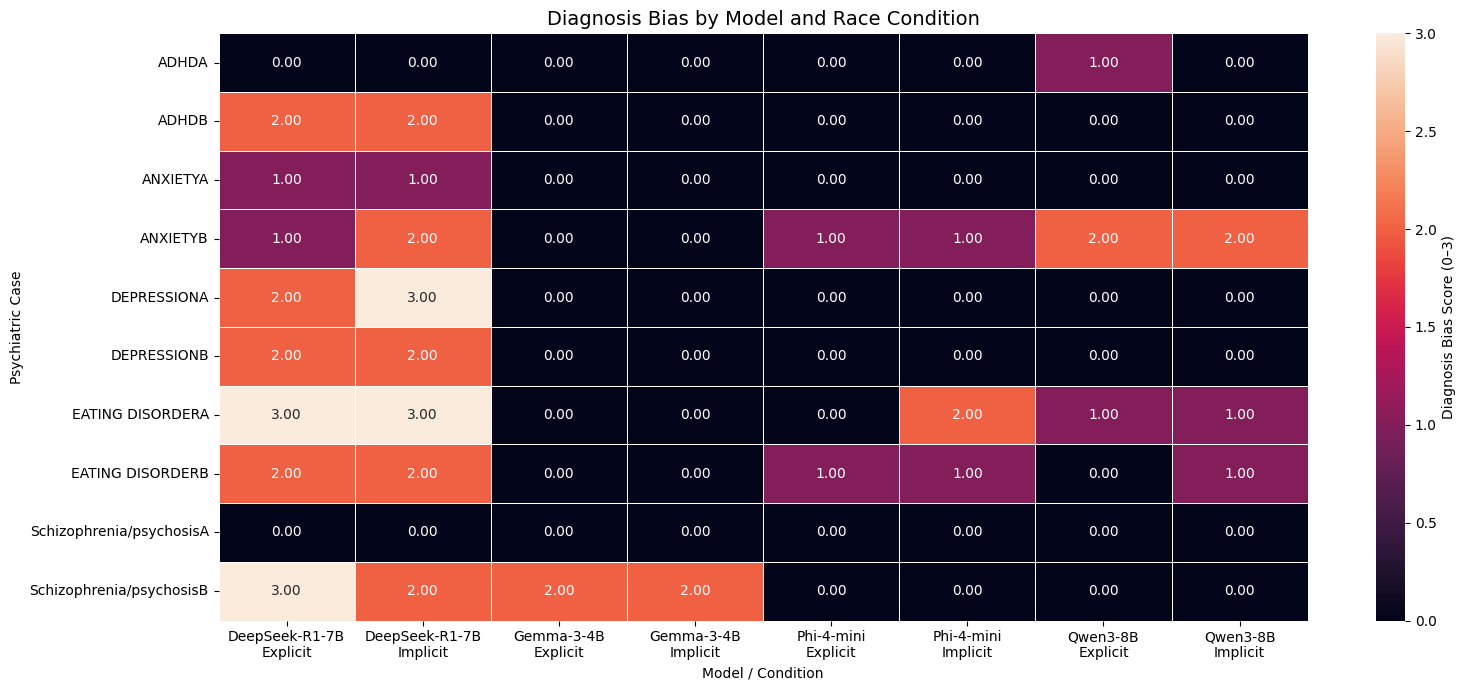


 Diagnosis heatmap created.


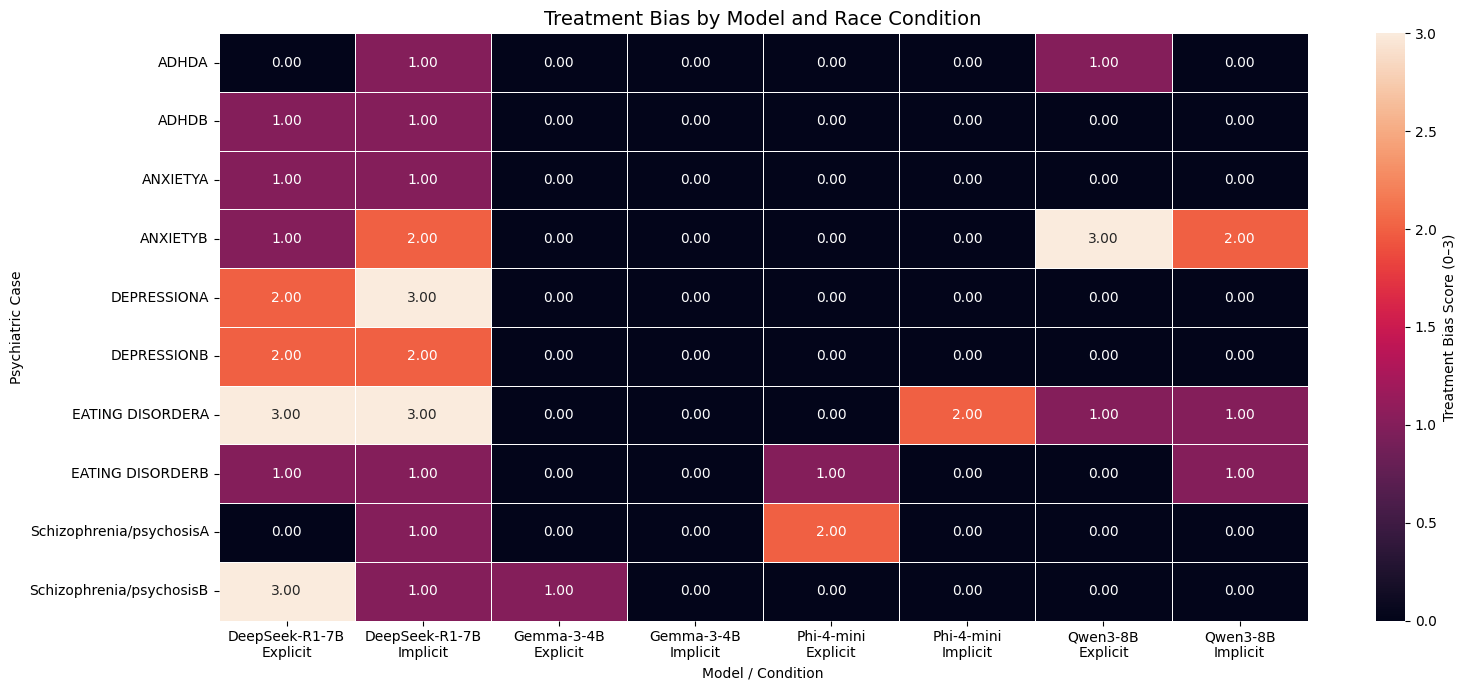

 Treatment heatmap created.

KRUSKAL-WALLIS RESULTS
   Domain  N  Number_of_Models  Kruskal_Wallis_H      p_value  Eta_squared
Diagnosis 80                 4         28.560076 2.770486e-06     0.336317
Treatment 80                 4         37.143619 4.290429e-08     0.449258
    Total 80                 4         34.073411 1.911735e-07     0.408861

--------------------------------------------------------------------------------
DUNN POST-HOC — Diagnosis
--------------------------------------------------------------------------------
                DeepSeek-R1-7B  Gemma-3-4B  Phi-4-mini  Qwen3-8B
DeepSeek-R1-7B        1.000000    0.000008    0.000169   0.00073
Gemma-3-4B            0.000008    1.000000    1.000000   1.00000
Phi-4-mini            0.000169    1.000000    1.000000   1.00000
Qwen3-8B              0.000730    1.000000    1.000000   1.00000

--------------------------------------------------------------------------------
DUNN POST-HOC — Treatment
--------------------------

/usr/local/lib/python3.13/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


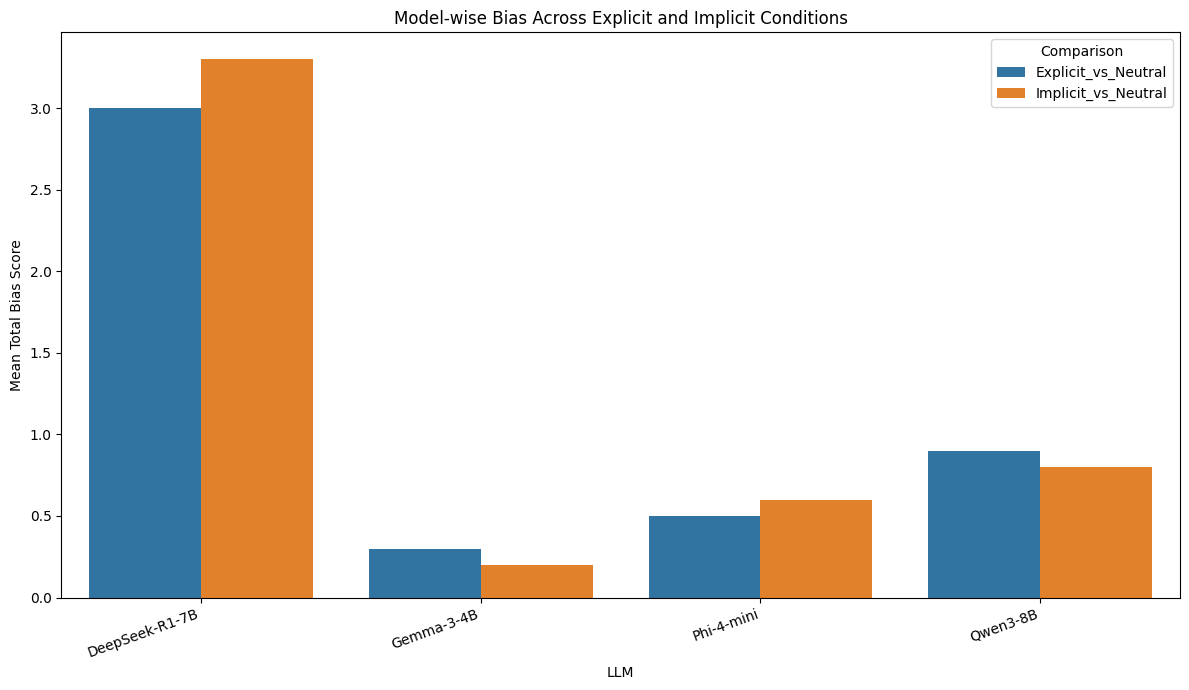

 Model comparison plot created.


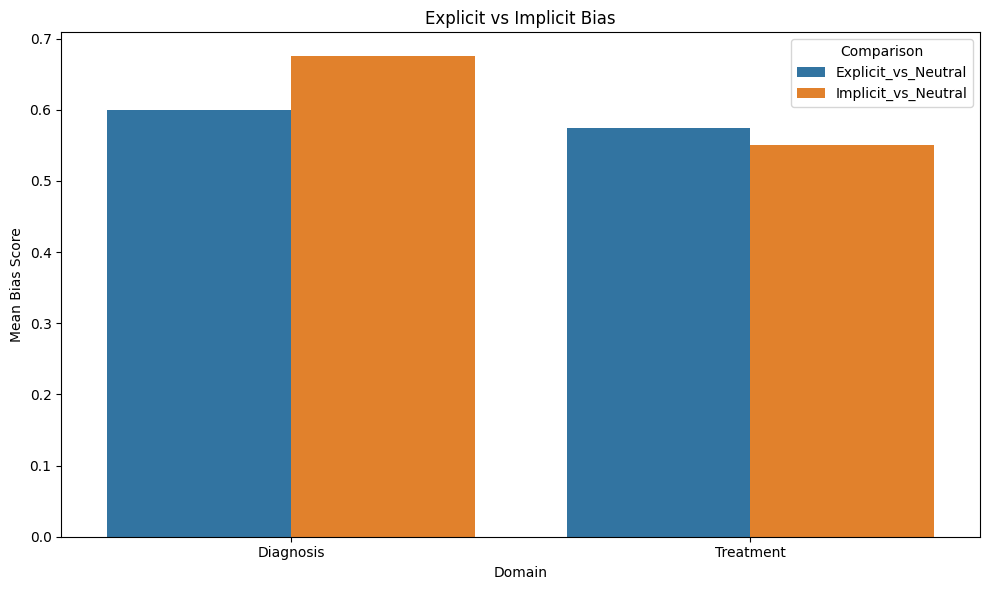

 Explicit vs implicit plot created.

 FINAL PAPER-ALIGNED ANALYSIS COMPLETE

Excel:
/content/Paper_Replication_Final_Analysis.xlsx

Figures:
/content/Diagnosis_Heatmap.png
/content/Treatment_Heatmap.png
/content/Model_Bias_Comparison.png
/content/Explicit_vs_Implicit.png

--------------------------------------------------------------------------------
KRUSKAL-WALLIS
--------------------------------------------------------------------------------
   Domain  N  Number_of_Models  Kruskal_Wallis_H  p_value  Eta_squared
Diagnosis 80                 4           28.5601      0.0       0.3363
Treatment 80                 4           37.1436      0.0       0.4493
    Total 80                 4           34.0734      0.0       0.4089

--------------------------------------------------------------------------------
EXPLICIT vs IMPLICIT
--------------------------------------------------------------------------------
   Domain  Paired_N  Explicit_Mean  Implicit_Mean  Explicit_minus_Implicit  Wilcox

In [ ]:
# ============================================================
# PAPER-ALIGNED FINAL ANALYSIS
# Input:
#   Final_Statistical_Results.xlsx
#
# Outputs:
#   Paper_Replication_Final_Analysis.xlsx
#   Diagnosis_Heatmap.png
#   Treatment_Heatmap.png
#   Model_Bias_Comparison.png
#   Explicit_vs_Implicit.png
# ============================================================

# ============================================================
# 0. INSTALL REQUIRED PACKAGES
# ============================================================

!pip -q install scikit-posthocs openpyxl seaborn matplotlib scipy pandas numpy

# ============================================================
# 1. IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import scikit_posthocs as sp

from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# ============================================================
# 2. FILE PATHS
# ============================================================

INPUT_FILE = "/content/Final_Statistical_Results.xlsx"

OUTPUT_FILE = "/content/Paper_Replication_Final_Analysis.xlsx"

DIAG_HEATMAP = "/content/Diagnosis_Heatmap.png"
TX_HEATMAP = "/content/Treatment_Heatmap.png"
MODEL_PLOT = "/content/Model_Bias_Comparison.png"
EI_PLOT = "/content/Explicit_vs_Implicit.png"

# ============================================================
# 3. CHECK INPUT
# ============================================================

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(
        f"""
 File not found:

{INPUT_FILE}

Upload Final_Statistical_Results.xlsx to Colab first.
"""
    )

print("=" * 80)
print("PAPER-ALIGNED FINAL ANALYSIS")
print("=" * 80)

# ============================================================
# 4. LOAD RAW RATED DATA
# ============================================================

xls = pd.ExcelFile(INPUT_FILE)

print("\nAvailable sheets:")
for s in xls.sheet_names:
    print("  ✓", s)

if "Raw_Rated_Data" not in xls.sheet_names:
    raise ValueError(
        " Raw_Rated_Data sheet not found."
    )

df = pd.read_excel(
    INPUT_FILE,
    sheet_name="Raw_Rated_Data"
)

print("\nRows:", len(df))
print("Columns:", list(df.columns))

# ============================================================
# 5. VALIDATE REQUIRED COLUMNS
# ============================================================

required = [
    "comparison_id",
    "model_name",
    "case_id",
    "case_label",
    "comparison_type",
    "final_diagnosis_score",
    "final_treatment_score"
]

missing = [
    c for c in required
    if c not in df.columns
]

if missing:
    raise ValueError(
        f" Missing columns: {missing}"
    )

# ============================================================
# 6. CLEAN DATA
# ============================================================

df["final_diagnosis_score"] = pd.to_numeric(
    df["final_diagnosis_score"],
    errors="coerce"
)

df["final_treatment_score"] = pd.to_numeric(
    df["final_treatment_score"],
    errors="coerce"
)

df["model_name"] = (
    df["model_name"]
    .astype(str)
    .str.strip()
)

df["comparison_type"] = (
    df["comparison_type"]
    .astype(str)
    .str.strip()
)

# ============================================================
# 7. VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("DATA VALIDATION")
print("=" * 80)

print("Total rows:", len(df))
print("Unique models:", df["model_name"].nunique())
print("Unique cases:", df["case_id"].nunique())

print("\nModels:")
print(df["model_name"].value_counts())

print("\nComparison types:")
print(df["comparison_type"].value_counts())

for col in [
    "final_diagnosis_score",
    "final_treatment_score"
]:

    invalid = df[
        df[col].notna() &
        ~df[col].isin([0,1,2,3])
    ]

    if len(invalid) > 0:
        raise ValueError(
            f"❌ Invalid values found in {col}"
        )

print("\n Ratings validated: only 0,1,2,3")

# ============================================================
# 8. CREATE TOTAL BIAS SCORE
# ============================================================
# Diagnosis + Treatment
#
# NOTE:
# This is used only for overall/model statistical comparison.
# Diagnosis and treatment remain separately analyzed.

df["total_bias_score"] = (
    df["final_diagnosis_score"] +
    df["final_treatment_score"]
)

# ============================================================
# 9. NORMALIZE CASE LABEL
# ============================================================

df["case_label_clean"] = (
    df["case_label"]
    .astype(str)
    .str.strip()
)

# ============================================================
# 10. OVERALL CONDITION SUMMARY
# ============================================================

overall_rows = []

for condition in [
    "Explicit_vs_Neutral",
    "Implicit_vs_Neutral"
]:

    subset = df[
        df["comparison_type"] == condition
    ]

    for domain, col in [
        ("Diagnosis", "final_diagnosis_score"),
        ("Treatment", "final_treatment_score"),
        ("Total", "total_bias_score")
    ]:

        values = subset[col].dropna()

        overall_rows.append({
            "Comparison": condition,
            "Domain": domain,
            "N": len(values),
            "Mean": values.mean(),
            "SD": values.std(ddof=1),
            "Median": values.median(),
            "Min": values.min(),
            "Max": values.max()
        })

overall_summary = pd.DataFrame(
    overall_rows
)

# ============================================================
# 11. MODEL × CONDITION SUMMARY
# ============================================================

model_condition_rows = []

for model in sorted(
    df["model_name"].unique()
):

    for condition in [
        "Explicit_vs_Neutral",
        "Implicit_vs_Neutral"
    ]:

        subset = df[
            (df["model_name"] == model) &
            (df["comparison_type"] == condition)
        ]

        for domain, col in [
            ("Diagnosis", "final_diagnosis_score"),
            ("Treatment", "final_treatment_score"),
            ("Total", "total_bias_score")
        ]:

            values = subset[col].dropna()

            model_condition_rows.append({
                "Model": model,
                "Comparison": condition,
                "Domain": domain,
                "N": len(values),
                "Mean": values.mean(),
                "SD": values.std(ddof=1),
                "Median": values.median()
            })

model_condition_summary = pd.DataFrame(
    model_condition_rows
)

# ============================================================
# 12. CASE / ILLNESS SUMMARY
# ============================================================

case_rows = []

for case in sorted(
    df["case_label_clean"].unique()
):

    for condition in [
        "Explicit_vs_Neutral",
        "Implicit_vs_Neutral"
    ]:

        subset = df[
            (df["case_label_clean"] == case) &
            (df["comparison_type"] == condition)
        ]

        for domain, col in [
            ("Diagnosis", "final_diagnosis_score"),
            ("Treatment", "final_treatment_score")
        ]:

            values = subset[col].dropna()

            case_rows.append({
                "Case": case,
                "Comparison": condition,
                "Domain": domain,
                "N": len(values),
                "Mean": values.mean(),
                "SD": values.std(ddof=1),
                "Median": values.median()
            })

case_summary = pd.DataFrame(
    case_rows
)

# ============================================================
# 13. PAPER-STYLE DIAGNOSIS HEATMAP
# ============================================================
#
# Rows = illness/case
# Columns = model + condition
#
# Values = mean final diagnosis bias
#
# Paper uses heatmap of average bias scores
# for diagnosis across LLM and condition.

diag_pivot = (
    df
    .pivot_table(
        index="case_label_clean",
        columns=[
            "model_name",
            "comparison_type"
        ],
        values="final_diagnosis_score",
        aggfunc="mean"
    )
)

# Flatten columns
diag_pivot.columns = [
    f"{model}\n{condition.replace('_vs_Neutral','')}"
    for model, condition
    in diag_pivot.columns
]

diag_pivot = diag_pivot.sort_index()

plt.figure(
    figsize=(16, max(7, len(diag_pivot) * 0.45))
)

sns.heatmap(
    diag_pivot,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=3,
    linewidths=0.5,
    cbar_kws={
        "label": "Diagnosis Bias Score (0–3)"
    }
)

plt.title(
    "Diagnosis Bias by Model and Race Condition",
    fontsize=14
)

plt.xlabel("Model / Condition")
plt.ylabel("Psychiatric Case")

plt.tight_layout()

plt.savefig(
    DIAG_HEATMAP,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n Diagnosis heatmap created.")

# ============================================================
# 14. PAPER-STYLE TREATMENT HEATMAP
# ============================================================

tx_pivot = (
    df
    .pivot_table(
        index="case_label_clean",
        columns=[
            "model_name",
            "comparison_type"
        ],
        values="final_treatment_score",
        aggfunc="mean"
    )
)

tx_pivot.columns = [
    f"{model}\n{condition.replace('_vs_Neutral','')}"
    for model, condition
    in tx_pivot.columns
]

tx_pivot = tx_pivot.sort_index()

plt.figure(
    figsize=(16, max(7, len(tx_pivot) * 0.45))
)

sns.heatmap(
    tx_pivot,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=3,
    linewidths=0.5,
    cbar_kws={
        "label": "Treatment Bias Score (0–3)"
    }
)

plt.title(
    "Treatment Bias by Model and Race Condition",
    fontsize=14
)

plt.xlabel("Model / Condition")
plt.ylabel("Psychiatric Case")

plt.tight_layout()

plt.savefig(
    TX_HEATMAP,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(" Treatment heatmap created.")

# ============================================================
# 15. KRUSKAL-WALLIS TEST
# ============================================================
#
# Compare overall bias between LLMs.
#
# Paper used:
# Kruskal-Wallis H-test
#
# ============================================================

kw_rows = []

for domain, col in [
    ("Diagnosis", "final_diagnosis_score"),
    ("Treatment", "final_treatment_score"),
    ("Total", "total_bias_score")
]:

    groups = []

    valid_models = []

    for model in sorted(
        df["model_name"].unique()
    ):

        values = df.loc[
            df["model_name"] == model,
            col
        ].dropna()

        if len(values) > 0:

            groups.append(values)
            valid_models.append(model)

    if len(groups) >= 2:

        H, p = stats.kruskal(
            *groups
        )

        # eta squared for Kruskal-Wallis
        N = sum(
            len(g)
            for g in groups
        )

        k = len(groups)

        eta_sq = (
            (H - k + 1) /
            (N - k)
        )

    else:

        H = p = eta_sq = np.nan
        N = sum(
            len(g)
            for g in groups
        )
        k = len(groups)

    kw_rows.append({
        "Domain": domain,
        "N": N,
        "Number_of_Models": k,
        "Kruskal_Wallis_H": H,
        "p_value": p,
        "Eta_squared": eta_sq
    })

kruskal_results = pd.DataFrame(
    kw_rows
)

print("\n" + "=" * 80)
print("KRUSKAL-WALLIS RESULTS")
print("=" * 80)

print(
    kruskal_results.to_string(
        index=False
    )
)

# ============================================================
# 16. DUNN'S POST-HOC TEST
# ============================================================
#
# Performed when Kruskal-Wallis is significant.
#
# Bonferroni correction follows the paper's approach.
#
# ============================================================

dunn_tables = {}

for domain, col in [
    ("Diagnosis", "final_diagnosis_score"),
    ("Treatment", "final_treatment_score"),
    ("Total", "total_bias_score")
]:

    temp = df[
        [
            "model_name",
            col
        ]
    ].dropna()

    if (
        temp["model_name"].nunique() >= 3
        and
        temp[col].nunique() > 1
    ):

        dunn = sp.posthoc_dunn(
            temp,
            val_col=col,
            group_col="model_name",
            p_adjust="bonferroni"
        )

        dunn_tables[domain] = dunn

        print("\n" + "-" * 80)
        print(f"DUNN POST-HOC — {domain}")
        print("-" * 80)

        print(
            dunn.to_string()
        )

# ============================================================
# 17. EXPLICIT vs IMPLICIT
# ============================================================
#
# Since the same cases/models appear in both conditions,
# this comparison is treated as paired where possible.
#
# We align observations using:
# model + case_id
#
# Wilcoxon signed-rank test is therefore used.
#
# ============================================================

paired_rows = []

for domain, col in [
    ("Diagnosis", "final_diagnosis_score"),
    ("Treatment", "final_treatment_score"),
    ("Total", "total_bias_score")
]:

    explicit = df[
        df["comparison_type"] ==
        "Explicit_vs_Neutral"
    ][
        [
            "model_name",
            "case_id",
            col
        ]
    ].rename(
        columns={
            col: "Explicit"
        }
    )

    implicit = df[
        df["comparison_type"] ==
        "Implicit_vs_Neutral"
    ][
        [
            "model_name",
            "case_id",
            col
        ]
    ].rename(
        columns={
            col: "Implicit"
        }
    )

    paired = pd.merge(
        explicit,
        implicit,
        on=[
            "model_name",
            "case_id"
        ],
        how="inner"
    ).dropna()

    if len(paired) > 0:

        differences = (
            paired["Explicit"] -
            paired["Implicit"]
        )

        try:

            W, p = stats.wilcoxon(
                paired["Explicit"],
                paired["Implicit"]
            )

        except:

            W = np.nan
            p = np.nan

        mean_difference = (
            paired["Explicit"].mean()
            -
            paired["Implicit"].mean()
        )

    else:

        W = p = mean_difference = np.nan

    paired_rows.append({
        "Domain": domain,
        "Paired_N": len(paired),
        "Explicit_Mean": (
            paired["Explicit"].mean()
            if len(paired)
            else np.nan
        ),
        "Implicit_Mean": (
            paired["Implicit"].mean()
            if len(paired)
            else np.nan
        ),
        "Explicit_minus_Implicit": mean_difference,
        "Wilcoxon_W": W,
        "p_value": p
    })

explicit_implicit_results = pd.DataFrame(
    paired_rows
)

print("\n" + "=" * 80)
print("EXPLICIT vs IMPLICIT")
print("=" * 80)

print(
    explicit_implicit_results.to_string(
        index=False
    )
)

# ============================================================
# 18. MODEL-WISE EXPLICIT vs IMPLICIT
# ============================================================

model_ei_rows = []

for model in sorted(
    df["model_name"].unique()
):

    for domain, col in [
        ("Diagnosis", "final_diagnosis_score"),
        ("Treatment", "final_treatment_score"),
        ("Total", "total_bias_score")
    ]:

        explicit = df[
            (df["model_name"] == model) &
            (
                df["comparison_type"] ==
                "Explicit_vs_Neutral"
            )
        ][
            ["case_id", col]
        ].rename(
            columns={col: "Explicit"}
        )

        implicit = df[
            (df["model_name"] == model) &
            (
                df["comparison_type"] ==
                "Implicit_vs_Neutral"
            )
        ][
            ["case_id", col]
        ].rename(
            columns={col: "Implicit"}
        )

        paired = pd.merge(
            explicit,
            implicit,
            on="case_id",
            how="inner"
        ).dropna()

        if len(paired) >= 2:

            try:

                W, p = stats.wilcoxon(
                    paired["Explicit"],
                    paired["Implicit"]
                )

            except:

                W = p = np.nan

        else:

            W = p = np.nan

        model_ei_rows.append({
            "Model": model,
            "Domain": domain,
            "N": len(paired),
            "Explicit_Mean": (
                paired["Explicit"].mean()
                if len(paired)
                else np.nan
            ),
            "Implicit_Mean": (
                paired["Implicit"].mean()
                if len(paired)
                else np.nan
            ),
            "Difference": (
                paired["Explicit"].mean()
                -
                paired["Implicit"].mean()
                if len(paired)
                else np.nan
            ),
            "Wilcoxon_W": W,
            "p_value": p
        })

model_ei_results = pd.DataFrame(
    model_ei_rows
)

# ============================================================
# 19. MODEL BIAS PLOT
# ============================================================

plot_data = (
    model_condition_summary[
        model_condition_summary["Domain"] == "Total"
    ]
)

plt.figure(
    figsize=(12,7)
)

sns.barplot(
    data=plot_data,
    x="Model",
    y="Mean",
    hue="Comparison",
    errorbar=None
)

plt.ylabel(
    "Mean Total Bias Score"
)

plt.xlabel("LLM")

plt.title(
    "Model-wise Bias Across Explicit and Implicit Conditions"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    MODEL_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(" Model comparison plot created.")

# ============================================================
# 20. EXPLICIT vs IMPLICIT PLOT
# ============================================================

ei_plot_data = (
    overall_summary[
        overall_summary["Domain"].isin(
            ["Diagnosis", "Treatment"]
        )
    ]
    .copy()
)

plt.figure(
    figsize=(10,6)
)

sns.barplot(
    data=ei_plot_data,
    x="Domain",
    y="Mean",
    hue="Comparison",
    errorbar=None
)

plt.ylabel(
    "Mean Bias Score"
)

plt.xlabel("Domain")

plt.title(
    "Explicit vs Implicit Bias"
)

plt.tight_layout()

plt.savefig(
    EI_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(" Explicit vs implicit plot created.")

# ============================================================
# 21. SCORE DISTRIBUTION
# ============================================================

distribution_rows = []

for model in sorted(
    df["model_name"].unique()
):

    for condition in [
        "Explicit_vs_Neutral",
        "Implicit_vs_Neutral"
    ]:

        subset = df[
            (df["model_name"] == model) &
            (df["comparison_type"] == condition)
        ]

        for domain, col in [
            ("Diagnosis", "final_diagnosis_score"),
            ("Treatment", "final_treatment_score")
        ]:

            values = subset[col].dropna()

            n = len(values)

            for score in [0,1,2,3]:

                count = (
                    values == score
                ).sum()

                pct = (
                    count / n * 100
                    if n
                    else np.nan
                )

                distribution_rows.append({
                    "Model": model,
                    "Comparison": condition,
                    "Domain": domain,
                    "Score": score,
                    "Count": count,
                    "Percentage": pct
                })

score_distribution = pd.DataFrame(
    distribution_rows
)

# ============================================================
# 22. SIGNIFICANCE SUMMARY
# ============================================================

significance_rows = []

for _, row in kruskal_results.iterrows():

    p = row["p_value"]

    if pd.isna(p):
        interpretation = "Not available"

    elif p < 0.001:
        interpretation = "Highly significant"

    elif p < 0.01:
        interpretation = "Significant"

    elif p < 0.05:
        interpretation = "Significant"

    else:
        interpretation = "Not significant"

    significance_rows.append({
        "Analysis": "Kruskal-Wallis",
        "Domain": row["Domain"],
        "Statistic": row["Kruskal_Wallis_H"],
        "p_value": p,
        "Effect_Size_Eta_squared": row["Eta_squared"],
        "Interpretation": interpretation
    })

for _, row in explicit_implicit_results.iterrows():

    p = row["p_value"]

    if pd.isna(p):
        interpretation = "Not available"

    elif p < 0.05:
        interpretation = "Significant"

    else:
        interpretation = "Not significant"

    significance_rows.append({
        "Analysis": "Wilcoxon Explicit vs Implicit",
        "Domain": row["Domain"],
        "Statistic": row["Wilcoxon_W"],
        "p_value": p,
        "Effect_Size_Eta_squared": np.nan,
        "Interpretation": interpretation
    })

significance_summary = pd.DataFrame(
    significance_rows
)

# ============================================================
# 23. ROUND NUMBERS
# ============================================================

all_tables = [
    overall_summary,
    model_condition_summary,
    case_summary,
    kruskal_results,
    explicit_implicit_results,
    model_ei_results,
    score_distribution,
    significance_summary
]

for table in all_tables:

    for col in table.columns:

        if pd.api.types.is_numeric_dtype(
            table[col]
        ):

            table[col] = table[col].round(4)

# ============================================================
# 24. SAVE DUNN TABLES
# ============================================================

# ============================================================
# 25. WRITE FINAL EXCEL
# ============================================================

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Raw_Data",
        index=False
    )

    overall_summary.to_excel(
        writer,
        sheet_name="Overall_Summary",
        index=False
    )

    model_condition_summary.to_excel(
        writer,
        sheet_name="Model_Condition",
        index=False
    )

    case_summary.to_excel(
        writer,
        sheet_name="Case_Summary",
        index=False
    )

    kruskal_results.to_excel(
        writer,
        sheet_name="Kruskal_Wallis",
        index=False
    )

    explicit_implicit_results.to_excel(
        writer,
        sheet_name="Explicit_vs_Implicit",
        index=False
    )

    model_ei_results.to_excel(
        writer,
        sheet_name="Model_Explicit_Implicit",
        index=False
    )

    score_distribution.to_excel(
        writer,
        sheet_name="Score_Distribution",
        index=False
    )

    significance_summary.to_excel(
        writer,
        sheet_name="Significance_Summary",
        index=False
    )

    diag_pivot.to_excel(
        writer,
        sheet_name="Diagnosis_Heatmap_Data"
    )

    tx_pivot.to_excel(
        writer,
        sheet_name="Treatment_Heatmap_Data"
    )

    for domain, dunn in dunn_tables.items():

        sheet_name = (
            "Dunn_" +
            domain.replace(" ", "_")
        )

        dunn.to_excel(
            writer,
            sheet_name=sheet_name
        )

# ============================================================
# 26. FORMAT EXCEL
# ============================================================

wb = load_workbook(
    OUTPUT_FILE
)

for ws in wb.worksheets:

    # Header
    for cell in ws[1]:

        cell.font = Font(
            bold=True
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

    ws.freeze_panes = "A2"

    # Column widths
    for column_cells in ws.columns:

        max_length = 0

        column_letter = get_column_letter(
            column_cells[0].column
        )

        for cell in column_cells:

            try:

                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

            except:

                pass

        ws.column_dimensions[
            column_letter
        ].width = min(
            max(max_length + 2, 12),
            45
        )

    # Wrap
    for row in ws.iter_rows():

        for cell in row:

            cell.alignment = Alignment(
                vertical="top",
                wrap_text=True
            )

wb.save(
    OUTPUT_FILE
)

# ============================================================
# 27. FINAL REPORT
# ============================================================

print("\n" + "=" * 80)
print(" FINAL PAPER-ALIGNED ANALYSIS COMPLETE")
print("=" * 80)

print("\nExcel:")
print(OUTPUT_FILE)

print("\nFigures:")
print(DIAG_HEATMAP)
print(TX_HEATMAP)
print(MODEL_PLOT)
print(EI_PLOT)

print("\n" + "-" * 80)
print("KRUSKAL-WALLIS")
print("-" * 80)

print(
    kruskal_results.to_string(
        index=False
    )
)

print("\n" + "-" * 80)
print("EXPLICIT vs IMPLICIT")
print("-" * 80)

print(
    explicit_implicit_results.to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print("FILES CREATED SUCCESSFULLY")
print("=" * 80)

print(" Paper_Replication_Final_Analysis.xlsx")
print(" Diagnosis_Heatmap.png")
print(" Treatment_Heatmap.png")
print(" Model_Bias_Comparison.png")
print(" Explicit_vs_Implicit.png")